# 4 — Incoherent Layers (thick substrates)

Real-world thin-film stacks often sit on a **thick substrate** (e.g. a 1 mm glass slide). Such substrates are much thicker than the coherence length of typical illumination, so light reflected from their two surfaces does **not** interfere with itself in practice.

A purely coherent solver, however, treats every layer as phase-coherent and produces dense Fabry–Perot ripples that don't appear in real measurements.

DiffTMM's `IncoherentIsotropicFilmSolver` lets you mark individual layers as coherent (`'c'`) or incoherent (`'i'`) via a `c_list`. Thin coatings stay coherent; thick substrates are treated incoherently — exactly matching `tmm_numpy.inc_tmm`.

Stack used below: `air | 100 nm TiO₂ | 1 mm glass | air`.

## 0 · Imports & device

In [1]:
import numpy as np
import torch
import matplotlib.pyplot as plt

from difftmm import IncoherentIsotropicFilmSolver, IsotropicFilmSolver

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

Using device: cuda


## 1 · The problem: dense Fabry–Perot ripples on a thick substrate

Sweep wavelength at normal incidence through a 100 nm TiO₂ film on a 1 mm glass slab. The coherent solver resolves the substrate's phase, producing ripples spaced by ~λ²/(2 n_sub d_sub) — much finer than any spectrometer can resolve.

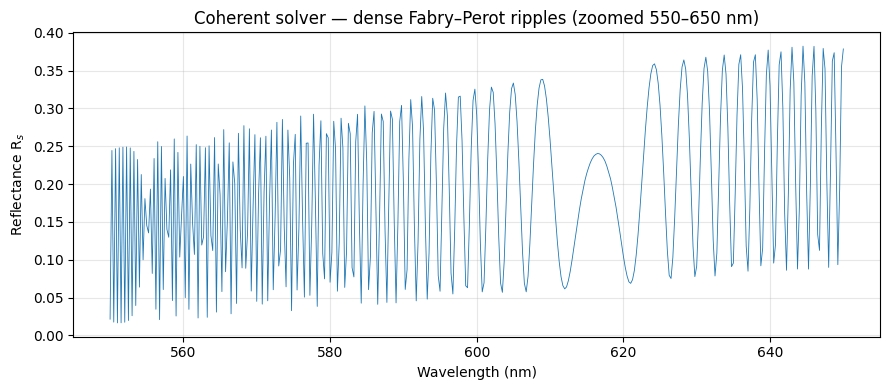

In [2]:
# Stack: air | 100 nm TiO2 | 1 mm glass | air
n_air = 1.0
n_film = 2.40 + 0.001j   # TiO2 with a touch of loss for numerical stability
n_sub = 1.52             # glass
d_film_um = 0.100        # 100 nm
d_sub_um = 1000.0        # 1 mm

wvln_nm = np.linspace(550, 650, 401)
wvln_um = (wvln_nm / 1000).tolist()
theta = torch.tensor([0.0], device=device)

coh_solver = IsotropicFilmSolver(
    mat_in=n_air,
    mat_out=n_air,
    mat_ls=[n_film, n_sub],
    thickness_ls=[d_film_um, d_sub_um],
    thickness_max=2 * d_sub_um,   # allow the 1 mm substrate
    device=device,
)
_, _, rs_coh, _ = coh_solver.simulate(theta=theta, wvln=wvln_um)
R_coh = (rs_coh[0, :, 0].abs() ** 2).cpu().numpy()

plt.figure(figsize=(9, 4))
plt.plot(wvln_nm, R_coh, color="#1f77b4", lw=0.6)
plt.xlabel("Wavelength (nm)")
plt.ylabel("Reflectance R$_s$")
plt.title("Coherent solver — dense Fabry–Perot ripples (zoomed 550–650 nm)")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## 2 · The fix: mark the substrate as incoherent

`c_list` specifies the coherence of each **interior** layer, in physical order. Here the 100 nm TiO₂ stays coherent (`'c'`) and the 1 mm glass is incoherent (`'i'`). The two semi-infinite media (air on both sides) are always incoherent.

The incoherent solver returns real power coefficients `(Rs, Rp, Ts, Tp)` rather than complex amplitudes.

In [3]:
inc_solver = IncoherentIsotropicFilmSolver(
    mat_in=n_air,
    mat_out=n_air,
    mat_ls=[n_film, n_sub],
    c_list=["c", "i"],            # TiO2 coherent, glass incoherent
    thickness_ls=[d_film_um, d_sub_um],
    thickness_max=2 * d_sub_um,
    device=device,
)
Rs_inc, Rp_inc, Ts_inc, Tp_inc = inc_solver.simulate(theta=theta, wvln=wvln_um)
R_inc = Rs_inc[0, :, 0].cpu().numpy()
T_inc = Ts_inc[0, :, 0].cpu().numpy()

print(f"Output shape: {Rs_inc.shape}  (batch, n_wvlns, n_angles)")
print(f"Energy check: max |R + T - 1| = {np.abs(R_inc + T_inc - 1).max():.2e}  (small residual from TiO2 absorption + float32 noise)")

Output shape: torch.Size([1, 401, 1])  (batch, n_wvlns, n_angles)
Energy check: max |R + T - 1| = 2.24e-03  (small residual from TiO2 absorption + float32 noise)


## 3 · Side-by-side comparison

The coherent curve oscillates wildly; the incoherent curve gives a smooth, measurable spectrum. The slow envelope of the coherent ripples coincides with the incoherent result.

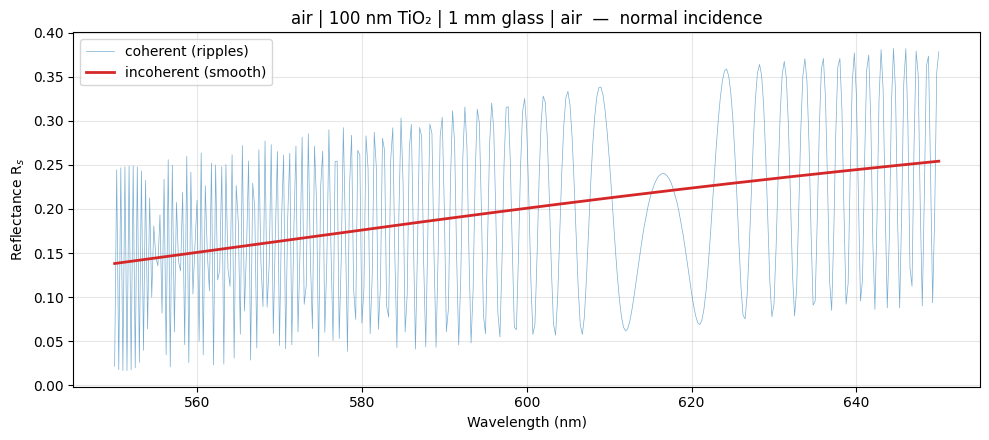

In [4]:
fig, ax = plt.subplots(figsize=(10, 4.5))
ax.plot(wvln_nm, R_coh, color="#1f77b4", lw=0.5, alpha=0.6, label="coherent (ripples)")
ax.plot(wvln_nm, R_inc, color="#d62728", lw=2.0, label="incoherent (smooth)")
ax.set_xlabel("Wavelength (nm)")
ax.set_ylabel("Reflectance R$_s$")
ax.set_title("air | 100 nm TiO₂ | 1 mm glass | air  —  normal incidence")
ax.grid(True, alpha=0.3)
ax.legend()
plt.tight_layout()
plt.show()

## 4 · Anti-reflection coating on a thick glass slide

A more practical example: a two-layer AR coating (TiO₂ + SiO₂) deposited on a 1 mm N-BK7 substrate. Sweep angle from 0° to 60° at 550 nm. Both polarisations are shown.

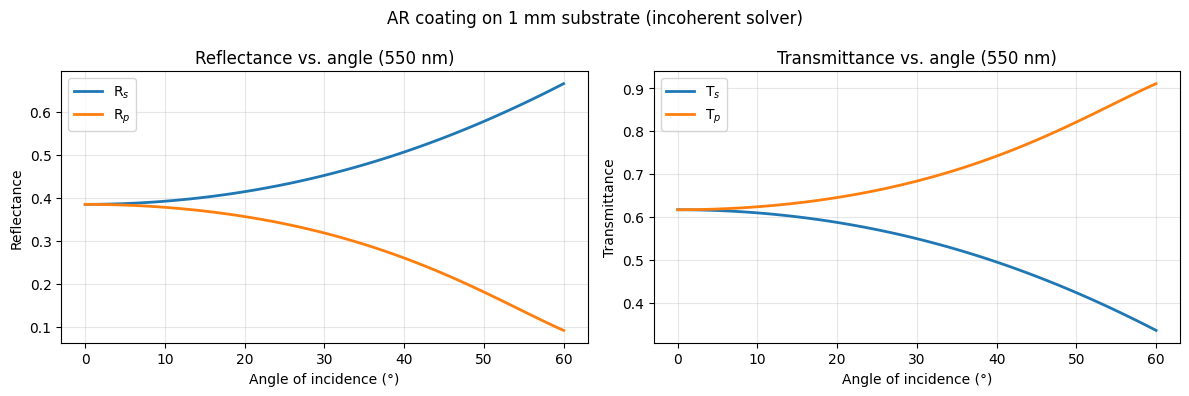

In [5]:
# Stack: air | 60 nm TiO2 | 100 nm SiO2 | 1 mm glass | air
n_tio2 = 2.40 + 0.001j
n_sio2 = 1.46
n_bk7 = 1.515

ar_solver = IncoherentIsotropicFilmSolver(
    mat_in=1.0,
    mat_out=1.0,
    mat_ls=[n_tio2, n_sio2, n_bk7],
    c_list=["c", "c", "i"],        # AR coatings coherent, substrate incoherent
    thickness_ls=[0.060, 0.100, 1000.0],
    thickness_max=2000.0,
    device=device,
)

angles_deg = np.linspace(0, 60, 121)
angles = torch.tensor(angles_deg * np.pi / 180, dtype=torch.float32, device=device)
wvln = torch.tensor([0.550], device=device)

Rs, Rp, Ts, Tp = ar_solver.simulate(theta=angles, wvln=wvln)
Rs_curve = Rs[0, 0, :].cpu().numpy()
Rp_curve = Rp[0, 0, :].cpu().numpy()
Ts_curve = Ts[0, 0, :].cpu().numpy()
Tp_curve = Tp[0, 0, :].cpu().numpy()

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].plot(angles_deg, Rs_curve, lw=2, label="R$_s$")
axes[0].plot(angles_deg, Rp_curve, lw=2, label="R$_p$")
axes[0].set_xlabel("Angle of incidence (°)")
axes[0].set_ylabel("Reflectance")
axes[0].set_title("Reflectance vs. angle (550 nm)")
axes[0].legend()
axes[0].grid(True, alpha=0.3)

axes[1].plot(angles_deg, Ts_curve, lw=2, label="T$_s$")
axes[1].plot(angles_deg, Tp_curve, lw=2, label="T$_p$")
axes[1].set_xlabel("Angle of incidence (°)")
axes[1].set_ylabel("Transmittance")
axes[1].set_title("Transmittance vs. angle (550 nm)")
axes[1].legend()
axes[1].grid(True, alpha=0.3)

fig.suptitle("AR coating on 1 mm substrate (incoherent solver)", fontsize=12)
plt.tight_layout()
plt.show()

## 5 · Differentiability

The incoherent solver is fully differentiable through layer thicknesses. As a clean demo, we minimize R$_s$ at 550 nm for a single-layer MgF₂ anti-reflection coating on a 1 mm glass slide.

Single-layer AR theory predicts the optimum thickness $d^* = \lambda / (4 n_{\text{MgF}_2}) \approx 99.6$ nm at 550 nm. The optimizer should converge there from a sub-optimal starting point — through the *incoherent* intensity-TMM.

MgF2 thickness: 50.0 nm  -->  99.6 nm
Analytical λ/(4n) optimum:           99.6 nm
R_s at 550 nm: 6.7279e-02  -->  5.3842e-02


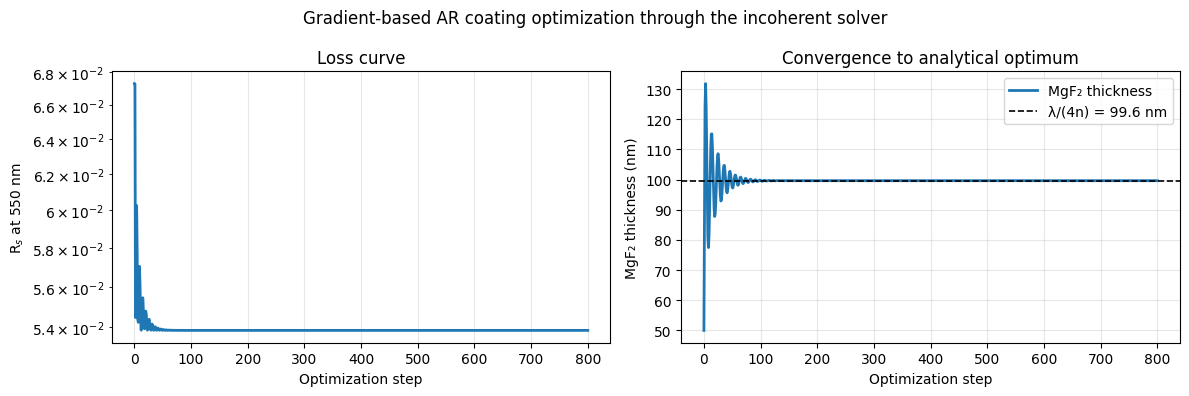

In [6]:
torch.manual_seed(0)

# Stack: air | MgF2 (variable) | 1 mm glass | air.
n_mgf2 = 1.38
n_glass = 1.515

opt_solver = IncoherentIsotropicFilmSolver(
    mat_in=1.0,
    mat_out=1.0,
    mat_ls=[n_mgf2, n_glass],
    c_list=["c", "i"],
    thickness_ls=[0.050, 1000.0],   # start MgF2 at 50 nm (too thin)
    thickness_min=0.0,
    thickness_max=2000.0,
    sigmoid_param=False,
    device=device,
)
opt_solver.film_params = opt_solver.film_params.detach().requires_grad_(True)

wvln_opt = torch.tensor([0.550], device=device)
theta_opt = torch.tensor([0.0], device=device)
optimizer = torch.optim.Adam([opt_solver.film_params], lr=2e-5)

d_start = opt_solver.get_film_thickness()[0, 0].item()
with torch.no_grad():
    R_start = opt_solver.simulate(theta=theta_opt, wvln=wvln_opt)[0][0, 0, 0].item()

mgf2_thicknesses = [d_start]
losses = [R_start]
for step in range(800):
    optimizer.zero_grad()
    Rs_opt, _, _, _ = opt_solver.simulate(theta=theta_opt, wvln=wvln_opt)
    loss = Rs_opt[0, 0, 0]
    loss.backward()
    # Freeze the substrate — its thickness has no physical effect in the incoherent solver.
    opt_solver.film_params.grad[..., -1] = 0
    optimizer.step()
    losses.append(loss.item())
    mgf2_thicknesses.append(opt_solver.get_film_thickness()[0, 0].item())

d_star = 0.550 / (4 * n_mgf2)   # analytical optimum, in um
print(f"MgF2 thickness: {mgf2_thicknesses[0]*1000:.1f} nm  -->  {mgf2_thicknesses[-1]*1000:.1f} nm")
print(f"Analytical λ/(4n) optimum:           {d_star*1000:.1f} nm")
print(f"R_s at 550 nm: {losses[0]:.4e}  -->  {losses[-1]:.4e}")

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].plot(losses, lw=2)
axes[0].set_xlabel("Optimization step")
axes[0].set_ylabel("R$_s$ at 550 nm")
axes[0].set_yscale("log")
axes[0].set_title("Loss curve")
axes[0].grid(True, alpha=0.3)

axes[1].plot(np.array(mgf2_thicknesses) * 1000, lw=2, label="MgF₂ thickness")
axes[1].axhline(d_star * 1000, color="k", ls="--", lw=1.2, label=f"λ/(4n) = {d_star*1000:.1f} nm")
axes[1].set_xlabel("Optimization step")
axes[1].set_ylabel("MgF₂ thickness (nm)")
axes[1].set_title("Convergence to analytical optimum")
axes[1].legend()
axes[1].grid(True, alpha=0.3)

fig.suptitle("Gradient-based AR coating optimization through the incoherent solver", fontsize=12)
plt.tight_layout()
plt.show()

## Summary

- `IncoherentIsotropicFilmSolver` marks each interior layer coherent (`'c'`) or incoherent (`'i'`) via `c_list`.
- Thick substrates (≫ source coherence length) should be `'i'`; thin films should be `'c'`.
- The semi-infinite media are always incoherent.
- Returns real power coefficients `(Rs, Rp, Ts, Tp)`; phase is discarded by design.
- Fully differentiable through layer thicknesses — usable for inverse design of stacks that include thick substrates.
- Currently 2×2 isotropic only; anisotropic incoherent TMM is future work.